# CV Robustness Project — Phases 4–7
### Corruption evaluation · Per-class analysis · Confusion matrices · Augmented model comparison

**Run baseline.ipynb first.** This notebook assumes the following already exist:
- `models/baseline_best.pth` — trained baseline checkpoint
- `model`, `DEVICE`, `CLASSES`, `test_dataset`, `test_loader`, `criterion` — still in memory

If you are starting a fresh kernel, **Cell 1** reloads everything from the checkpoint.

---
## Cell 1 — Reload baseline model from checkpoint (run if kernel was restarted)

In [1]:
import os, json, time
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from PIL import Image, ImageFilter
import seaborn as sns
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
np.random.seed(42)

# ── Device (same logic as baseline.ipynb) ────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.dirname(os.path.abspath('baseline.ipynb'))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
MODEL_DIR   = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
for d in [MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Constants (must match baseline.ipynb) ─────────────────────────────────────
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
BATCH_SIZE   = 128
NUM_WORKERS  = 0      # 0 avoids Mac multiprocessing errors

# ── Test dataset (no augmentation — deterministic) ────────────────────────────
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True, transform=test_transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
CLASSES = test_dataset.classes

# ── Rebuild the same model architecture ───────────────────────────────────────
# Architecture must be identical to what was used in baseline.ipynb
# before loading the saved weights — otherwise shapes won't match.
def build_resnet18():
    m = models.resnet18(weights=None)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(m.fc.in_features, 10)
    return m

model = build_resnet18().to(DEVICE)

# ── Load saved weights ────────────────────────────────────────────────────────
CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'baseline_best.pth')
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

# Handles both formats: plain state_dict or full checkpoint dict
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', '?')} "
          f"— saved accuracy: {checkpoint.get('best_acc', '?'):.4f}")
else:
    model.load_state_dict(checkpoint)
    print('Loaded plain state_dict from checkpoint.')

model.eval()
criterion = nn.CrossEntropyLoss()
print('Model ready.')

Device: mps


100%|██████████| 170M/170M [00:03<00:00, 48.4MB/s] 


Loaded plain state_dict from checkpoint.
Model ready.


---
## Cell 2 — Evaluate baseline on the clean test set

This is the reference accuracy. Every corruption result will be compared against this number.

In [2]:
# Reuse the exact same evaluate() function from the training loop
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


clean_loss, clean_acc = evaluate(model, test_loader, criterion)
print(f'Baseline clean test accuracy : {clean_acc:.4f}  ({clean_acc*100:.2f}%)')
print(f'Baseline clean test loss     : {clean_loss:.4f}')

# Save to JSON  (appended to in later cells)
baseline_results = {'clean_accuracy': round(clean_acc, 6)}
with open(os.path.join(RESULTS_DIR, 'baseline_clean.json'), 'w') as f:
    json.dump(baseline_results, f, indent=2)
print('Saved → results/baseline_clean.json')

Baseline clean test accuracy : 0.9533  (95.33%)
Baseline clean test loss     : 0.1891
Saved → results/baseline_clean.json


---
## Cell 3 — Corruption functions

**Why corruptions operate on raw tensors in [0, 1] before normalisation:**

The pipeline order is `image → corruption → ToTensor → Normalize`. 
Noise and blur are defined in terms of natural image statistics (pixel brightness 0–255, or 0–1 after `ToTensor`). 
If you corrupt *after* normalisation, a `variance=0.1` Gaussian noise would mean something completely different 
because the pixel scale has changed. So the `CorruptedDataset` wrapper below applies corruptions 
after `ToTensor` (values 0–1) but **before** the Normalize step.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CORRUPTION 1 — Gaussian Noise
# Adds random static sampled from a Gaussian distribution.
# 'variance' controls severity: 0.01 = barely visible, 0.5 = very heavy.
# ─────────────────────────────────────────────────────────────────────────────
def corrupt_gaussian_noise(img_tensor, variance):
    """
    img_tensor : float32 tensor (C, H, W) with values in [0, 1]
    variance   : noise strength — higher = more corrupt
    Returns    : corrupted tensor clamped back to [0, 1]
    """
    noise = torch.randn_like(img_tensor) * (variance ** 0.5)
    return (img_tensor + noise).clamp(0.0, 1.0)


# ─────────────────────────────────────────────────────────────────────────────
# CORRUPTION 2 — Gaussian Blur
# Simulates an out-of-focus lens. Larger kernel = more blurry.
# kernel_size must be an odd integer (PIL requirement).
# ─────────────────────────────────────────────────────────────────────────────
def corrupt_gaussian_blur(img_tensor, kernel_size):
    """
    img_tensor  : float32 tensor (C, H, W) with values in [0, 1]
    kernel_size : odd integer — 3=mild, 5=moderate, 7+=heavy
    """
    # Convert tensor → PIL image so we can use PIL's GaussianBlur.
    # PIL's radius ≈ kernel_size / 2 (they use different parameterisations).
    pil_img = transforms.ToPILImage()(img_tensor)
    radius  = kernel_size / 2.0
    blurred = pil_img.filter(ImageFilter.GaussianBlur(radius=radius))
    return transforms.ToTensor()(blurred)   # back to (C, H, W) float32 in [0,1]


# ─────────────────────────────────────────────────────────────────────────────
# CORRUPTION 3 — Rotation
# Tilts the image by a fixed angle. Corners are filled with black (0).
# A model trained only on upright images struggles with rotated inputs.
# ─────────────────────────────────────────────────────────────────────────────
def corrupt_rotation(img_tensor, angle):
    """
    img_tensor : float32 tensor (C, H, W) with values in [0, 1]
    angle      : degrees to rotate — 15, 30, 45, 60, 90
    """
    pil_img = transforms.ToPILImage()(img_tensor)
    rotated = transforms.functional.rotate(pil_img, angle, fill=0)
    return transforms.ToTensor()(rotated)


# ─────────────────────────────────────────────────────────────────────────────
# CORRUPTION 4 — Occlusion (random square patch)
# Blacks out a randomly placed square region of the image.
# Simulates real obstructions: a hand in front of a camera, a sticker, etc.
# ─────────────────────────────────────────────────────────────────────────────
def corrupt_occlusion(img_tensor, patch_size):
    """
    img_tensor : float32 tensor (C, H, W) with values in [0, 1]
    patch_size : side length in pixels — 4, 6, 8, 12, 16
    """
    _, H, W  = img_tensor.shape
    img      = img_tensor.clone()
    # Random top-left corner, ensuring the patch fits within the image
    x = np.random.randint(0, W - patch_size + 1)
    y = np.random.randint(0, H - patch_size + 1)
    img[:, y:y + patch_size, x:x + patch_size] = 0.0
    return img


print('Corruption functions defined:')
print('  corrupt_gaussian_noise (variance)')
print('  corrupt_gaussian_blur  (kernel_size)')
print('  corrupt_rotation       (angle)')
print('  corrupt_occlusion      (patch_size)')

Corruption functions defined:
  corrupt_gaussian_noise (variance)
  corrupt_gaussian_blur  (kernel_size)
  corrupt_rotation       (angle)
  corrupt_occlusion      (patch_size)


---
## Cell 4 — CorruptedDataset wrapper

This class sits on top of the existing `test_dataset` and applies a corruption 
to every image *on the fly* as it is loaded, without modifying the original data.

In [4]:
class CorruptedDataset(torch.utils.data.Dataset):
    """
    Wraps a base dataset and applies a corruption + normalisation to each image.

    Ordering: base_dataset returns (ToTensor image in [0,1], label)
              → corrupt_fn runs on [0,1] tensor
              → normalise converts to the model's expected input range

    This preserves the correct pipeline order:
        image → ToTensor → corruption ([0,1] space) → Normalize
    """
    def __init__(self, base_dataset, corrupt_fn, severity, normalise_transform):
        """
        base_dataset        : dataset that returns (tensor in [0,1], label)
                              (test_dataset with ONLY ToTensor, not Normalize)
        corrupt_fn          : one of the four corruption functions above
        severity            : the severity value passed to corrupt_fn
        normalise_transform : transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
        """
        self.base       = base_dataset
        self.corrupt_fn = corrupt_fn
        self.severity   = severity
        self.normalise  = normalise_transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]              # img is (C,H,W) float32 in [0,1]
        img = self.corrupt_fn(img, self.severity) # apply corruption in [0,1] space
        img = self.normalise(img)                 # shift to model's expected range
        return img, label


# ── Base test dataset: ToTensor only, NO Normalize yet ────────────────────────
# The Normalize step is handled inside CorruptedDataset so corruptions
# always operate on [0, 1] pixel space, not the normalised space.
test_dataset_raw = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=transforms.ToTensor(),   # [0,1] only — no Normalize
)

normalise = transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)

print('CorruptedDataset class defined.')
print('test_dataset_raw ready (ToTensor only, 10,000 images).')

CorruptedDataset class defined.
test_dataset_raw ready (ToTensor only, 10,000 images).


---
## Cell 5 — Visualise corruptions at all severity levels

Before running evaluation, confirm visually that each corruption looks correct.

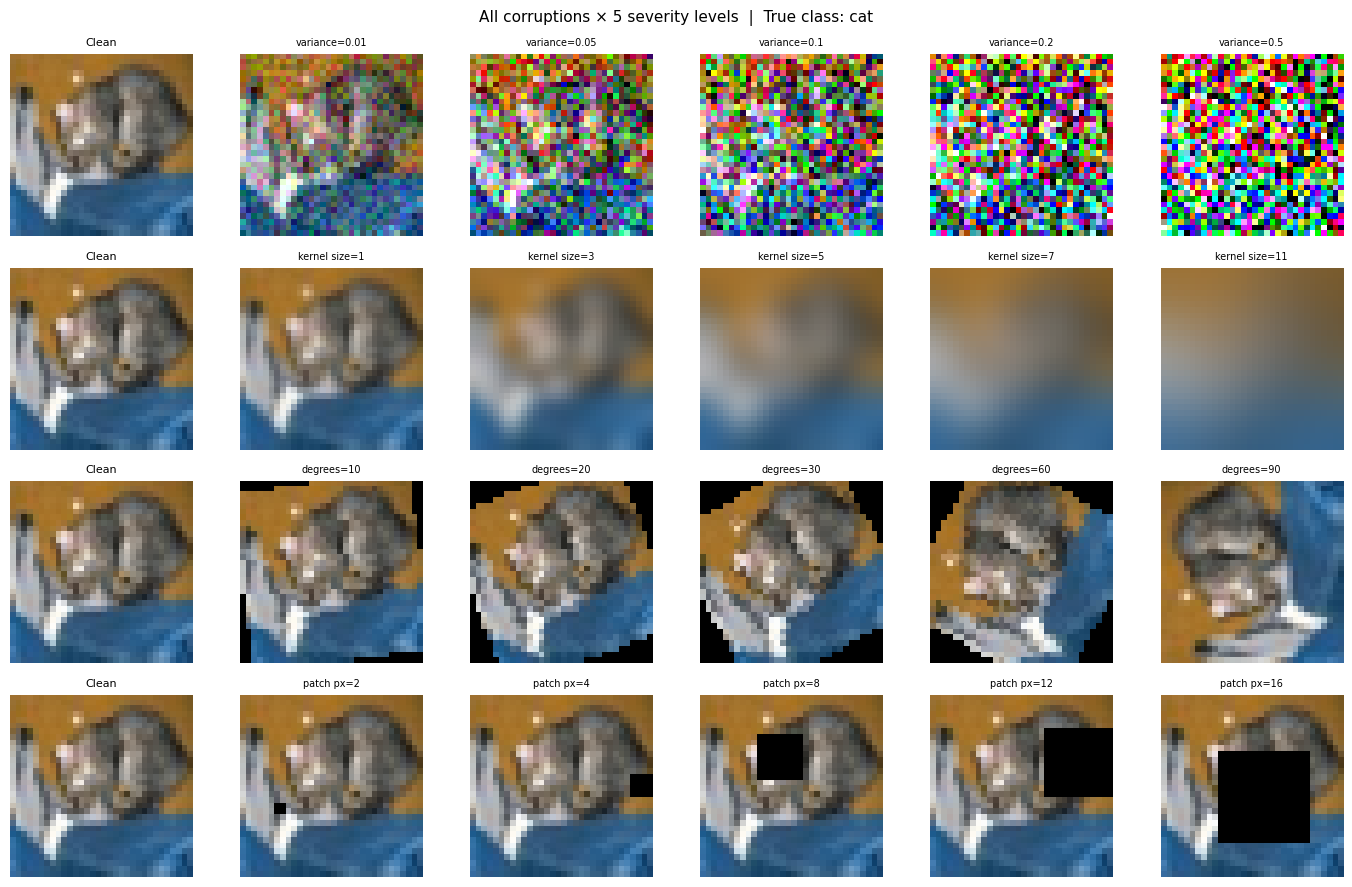

Saved → results/corruption_preview.png


In [5]:
# Severity levels used throughout the project
# Each list contains 5 levels from mild (index 0) to severe (index 4)
SEVERITIES = {
    'Gaussian Noise'  : {'fn': corrupt_gaussian_noise, 'levels': [0.01, 0.05, 0.1, 0.2, 0.5],  'label': 'variance'},
    'Gaussian Blur'   : {'fn': corrupt_gaussian_blur,  'levels': [1, 3, 5, 7, 11],              'label': 'kernel size'},
    'Rotation'        : {'fn': corrupt_rotation,       'levels': [10, 20, 30, 60, 90],          'label': 'degrees'},
    'Occlusion'       : {'fn': corrupt_occlusion,      'levels': [2, 4, 8, 12, 16],             'label': 'patch px'},
}

# Pick one fixed test image to demonstrate all corruptions
sample_img_raw, sample_label = test_dataset_raw[0]

fig, axes = plt.subplots(4, 6, figsize=(14, 9))

for row_idx, (corruption_name, cfg) in enumerate(SEVERITIES.items()):
    fn     = cfg['fn']
    levels = cfg['levels']
    label  = cfg['label']

    # Column 0: original clean image
    axes[row_idx, 0].imshow(sample_img_raw.permute(1, 2, 0).numpy())
    axes[row_idx, 0].set_title('Clean', fontsize=8)
    axes[row_idx, 0].axis('off')

    # Columns 1–5: one per severity level
    for col_idx, sev in enumerate(levels):
        corrupted = fn(sample_img_raw.clone(), sev)
        # Clamp to [0,1] for display (corruptions are designed to stay in range)
        display   = corrupted.permute(1, 2, 0).numpy().clip(0, 1)
        axes[row_idx, col_idx + 1].imshow(display)
        axes[row_idx, col_idx + 1].set_title(f'{label}={sev}', fontsize=7)
        axes[row_idx, col_idx + 1].axis('off')

    axes[row_idx, 0].set_ylabel(corruption_name, fontsize=9, rotation=90, labelpad=4)

plt.suptitle(f'All corruptions × 5 severity levels  |  True class: {CLASSES[sample_label]}',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'corruption_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/corruption_preview.png')

---
## Cell 6 — Evaluate baseline across all corruptions & severities

This is the core robustness evaluation. For every corruption type and every severity level 
we build a corrupted version of the 10,000-image test set and measure accuracy. 
The result is a table: rows = corruption type, columns = severity level.

In [6]:
def evaluate_corruption(model, corrupt_fn, severity, criterion):
    """
    Build a corrupted DataLoader for one (corruption_fn, severity) pair
    and return (loss, accuracy) using the same evaluate() function as training.
    """
    corrupted_ds = CorruptedDataset(test_dataset_raw, corrupt_fn, severity, normalise)
    corrupted_loader = torch.utils.data.DataLoader(
        corrupted_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    return evaluate(model, corrupted_loader, criterion)


# ── Run the full evaluation grid ──────────────────────────────────────────────
# corruption_results[name] = list of accuracies, one per severity level
corruption_results = {}

print(f'Clean baseline accuracy: {clean_acc:.4f}\n')
print(f'{"Corruption":<18}  {"Severity levels →":>10}')
print('-' * 70)

for name, cfg in SEVERITIES.items():
    accs   = []
    fn     = cfg['fn']
    levels = cfg['levels']

    for sev in levels:
        _, acc = evaluate_corruption(model, fn, sev, criterion)
        accs.append(acc)

    corruption_results[name] = accs

    # Show accuracy and drop from clean for each severity
    acc_str  = '  '.join(f'{a:.3f}' for a in accs)
    drop_str = '  '.join(f'−{clean_acc - a:.3f}' for a in accs)
    print(f'{name:<18}  acc: {acc_str}')
    print(f'{"":<18}  Δ  : {drop_str}')
    print()

print('Evaluation complete.')

Clean baseline accuracy: 0.9533

Corruption          Severity levels →
----------------------------------------------------------------------
Gaussian Noise      acc: 0.249  0.113  0.107  0.103  0.104
                    Δ  : −0.704  −0.841  −0.846  −0.850  −0.849

Gaussian Blur       acc: 0.940  0.181  0.171  0.173  0.172
                    Δ  : −0.014  −0.772  −0.782  −0.780  −0.781

Rotation            acc: 0.871  0.650  0.432  0.260  0.414
                    Δ  : −0.083  −0.304  −0.521  −0.693  −0.539

Occlusion           acc: 0.943  0.940  0.915  0.851  0.707
                    Δ  : −0.011  −0.013  −0.038  −0.102  −0.246

Evaluation complete.


---
## Cell 7 — Accuracy degradation curves

One plot per corruption type. The x-axis is severity, y-axis is accuracy. 
The dashed line marks clean baseline accuracy so the drop is immediately visible.

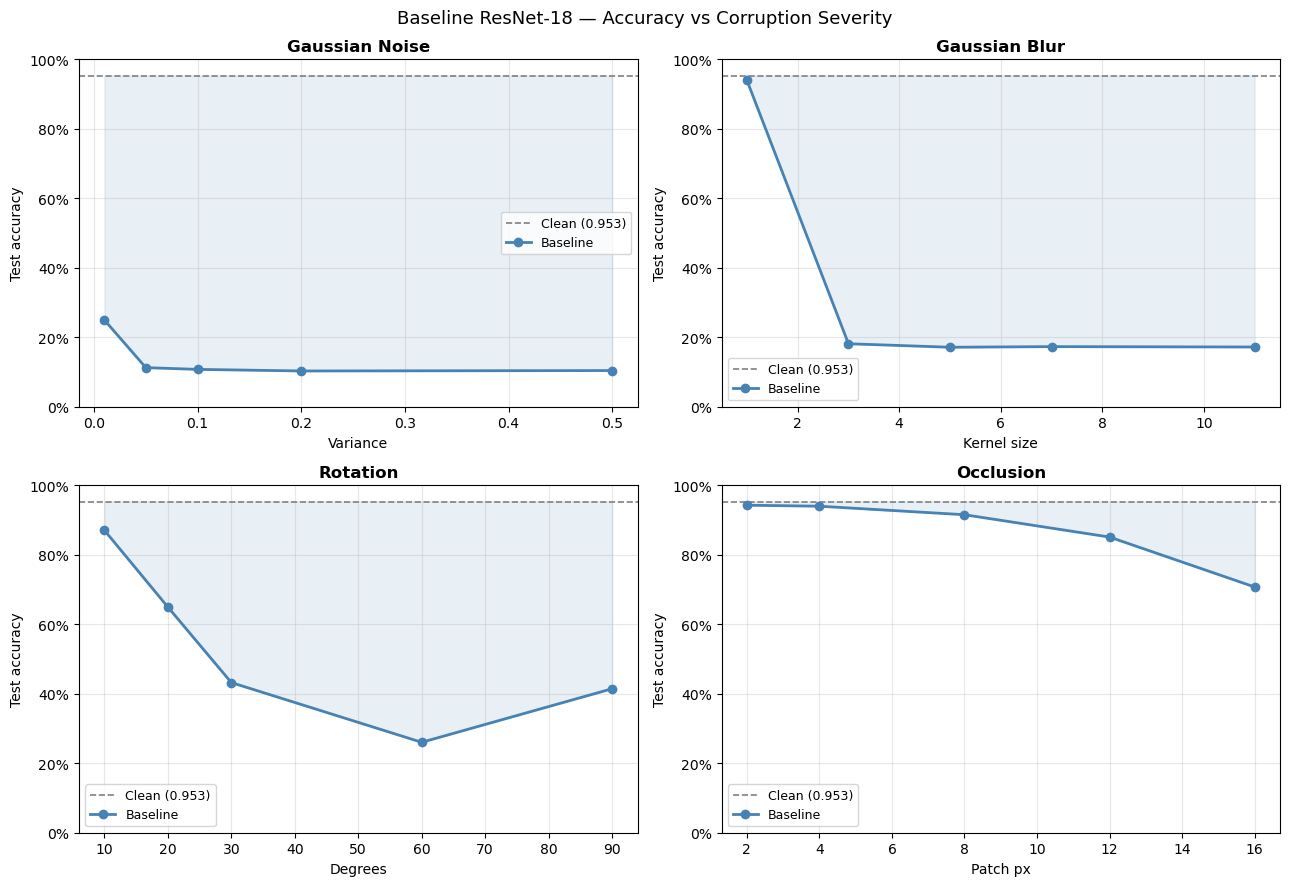

Saved → results/baseline_degradation_curves.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes      = axes.flatten()

colors = {'baseline': 'steelblue', 'augmented': 'tomato'}

for idx, (name, cfg) in enumerate(SEVERITIES.items()):
    ax     = axes[idx]
    levels = cfg['levels']
    accs   = corruption_results[name]

    # Clean baseline reference line
    ax.axhline(y=clean_acc, color='gray', linestyle='--',
               linewidth=1.2, label=f'Clean ({clean_acc:.3f})')

    # Accuracy at each severity level
    ax.plot(levels, accs,
            marker='o', linewidth=2, color=colors['baseline'],
            markersize=6, label='Baseline')

    # Shade the drop region
    ax.fill_between(levels, accs, clean_acc, alpha=0.12, color=colors['baseline'])

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(cfg['label'].capitalize(), fontsize=10)
    ax.set_ylabel('Test accuracy', fontsize=10)
    ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

plt.suptitle('Baseline ResNet-18 — Accuracy vs Corruption Severity', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'baseline_degradation_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/baseline_degradation_curves.png')

---
## Cell 8 — Per-class accuracy under each corruption (worst severity)

Some classes are inherently harder to recognise when corrupted. 
For example, 'cat' and 'dog' look similar and are often confused — 
blur and noise may push them across each other's decision boundary 
more easily than distinct classes like 'ship' or 'airplane'.

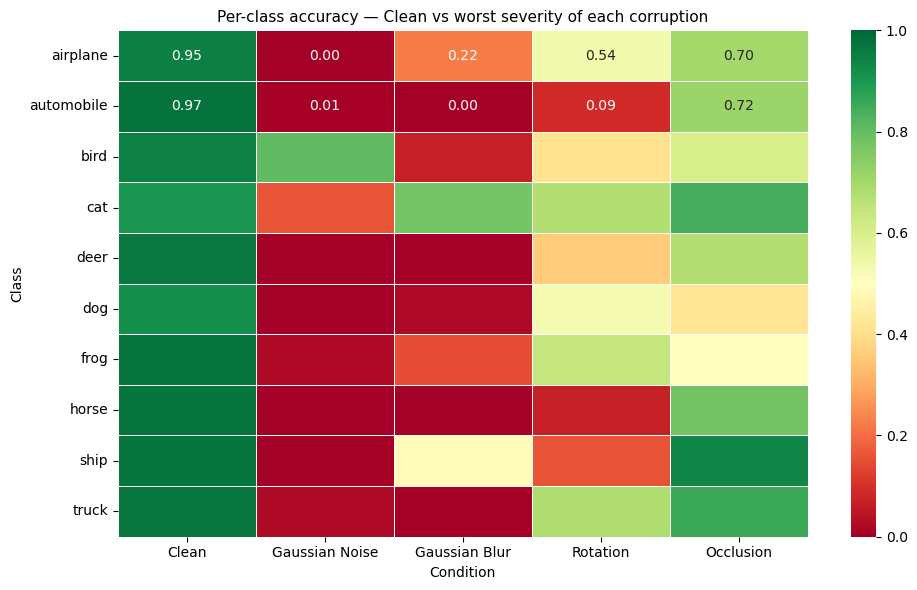

Saved → results/per_class_accuracy_heatmap.png


In [8]:
def per_class_accuracy(model, loader):
    """
    Run model on loader and return per-class accuracy.
    Returns dict {class_name: accuracy}.
    """
    model.eval()
    class_correct = [0] * 10
    class_total   = [0] * 10

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(1)

            for label, pred in zip(labels, preds):
                class_total[label]   += 1
                class_correct[label] += (label == pred).item()

    return {CLASSES[i]: class_correct[i] / class_total[i]
            for i in range(10)}


# ── Compute per-class accuracy for clean + worst severity of each corruption ──
clean_class_acc = per_class_accuracy(model, test_loader)

# Evaluate at the WORST severity level for each corruption
worst_class_accs = {}
for name, cfg in SEVERITIES.items():
    worst_sev = cfg['levels'][-1]       # last = most severe
    corrupted_ds = CorruptedDataset(test_dataset_raw, cfg['fn'], worst_sev, normalise)
    loader = torch.utils.data.DataLoader(
        corrupted_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
    )
    worst_class_accs[name] = per_class_accuracy(model, loader)

# ── Plot: heatmap of per-class accuracy under each condition ──────────────────
conditions = ['Clean'] + list(SEVERITIES.keys())
matrix     = np.zeros((len(CLASSES), len(conditions)))

for col, cond in enumerate(conditions):
    acc_dict = clean_class_acc if cond == 'Clean' else worst_class_accs[cond]
    for row, cls in enumerate(CLASSES):
        matrix[row, col] = acc_dict[cls]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0.0, vmax=1.0,
    xticklabels=conditions,
    yticklabels=CLASSES,
    ax=ax,
    linewidths=0.4,
)
ax.set_title('Per-class accuracy — Clean vs worst severity of each corruption', fontsize=11)
ax.set_xlabel('Condition')
ax.set_ylabel('Class')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_accuracy_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/per_class_accuracy_heatmap.png')

---
## Cell 9 — Confusion matrices

A confusion matrix shows which classes the model mistakes for each other. 
Each row is the true label; each column is the predicted label. 
Perfect classification = all weight on the diagonal. 
Off-diagonal entries reveal specific class pairs that get confused.

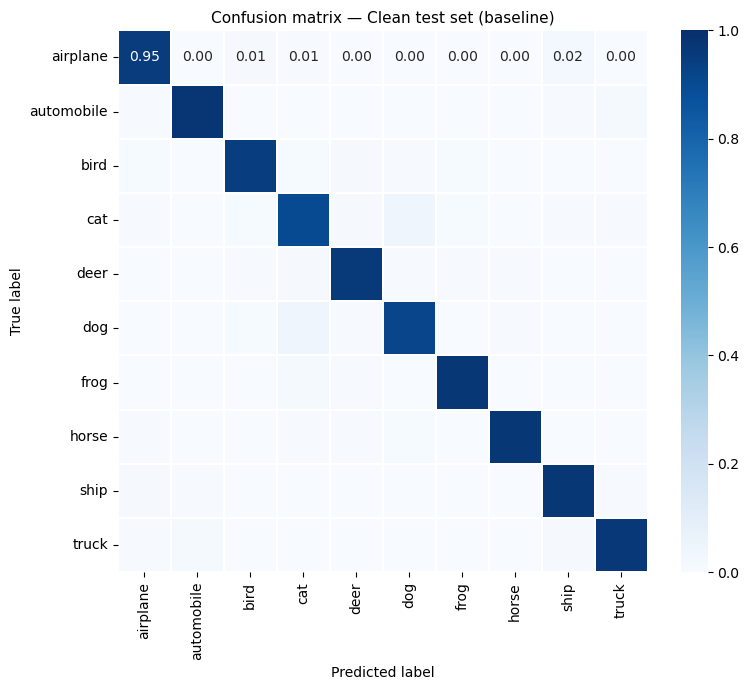

Saved → results/cm_clean.png


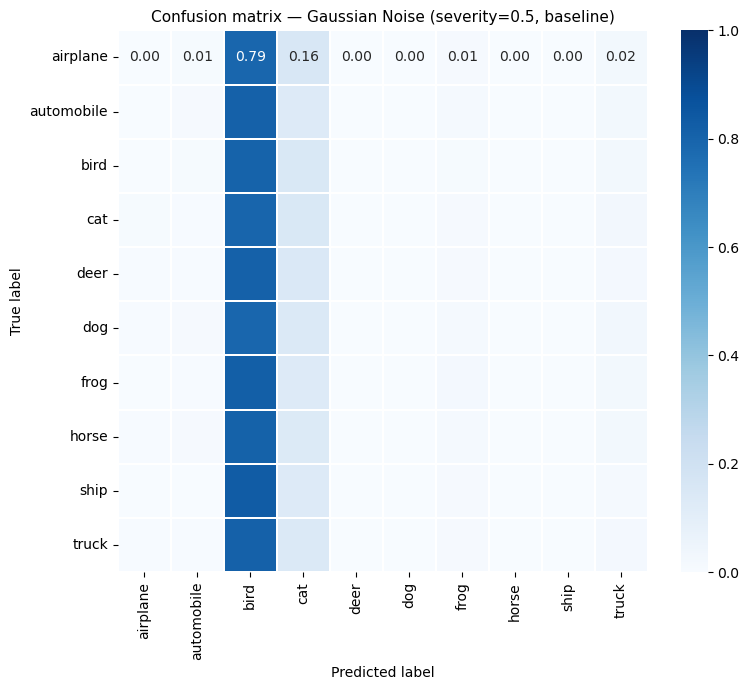

Saved → results/cm_gaussian_noise_worst.png


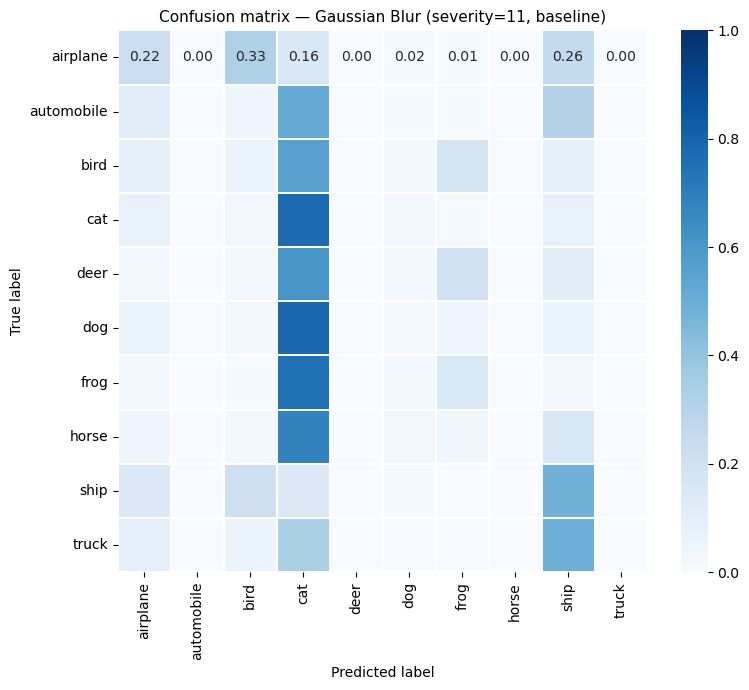

Saved → results/cm_gaussian_blur_worst.png


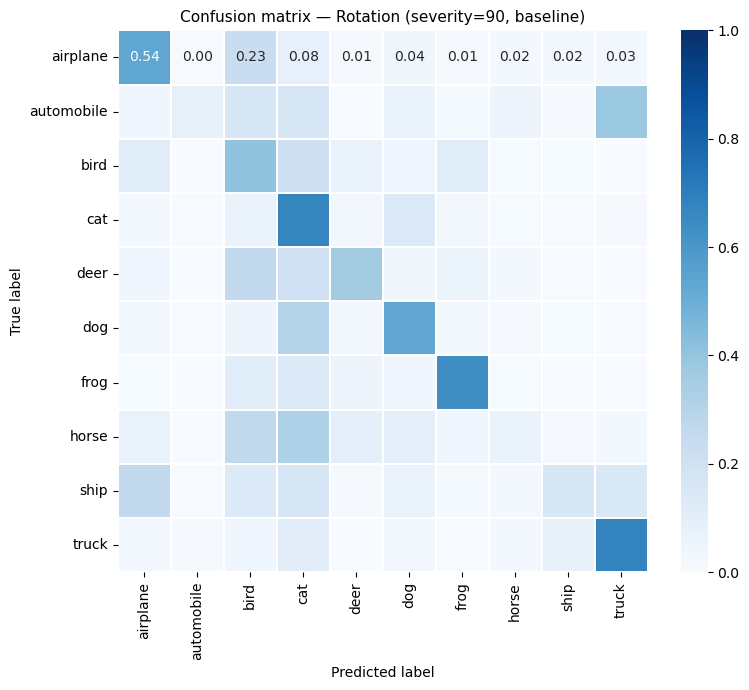

Saved → results/cm_rotation_worst.png


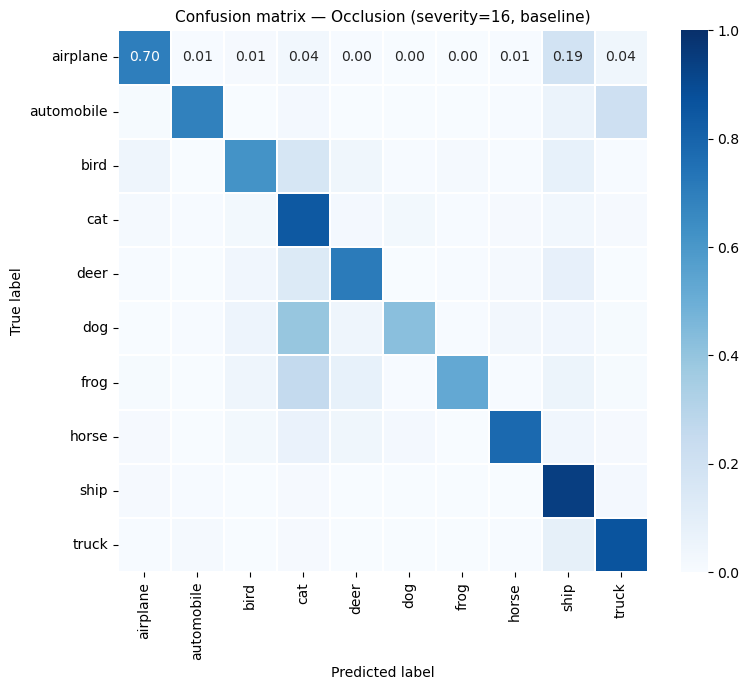

Saved → results/cm_occlusion_worst.png


In [9]:
def get_all_predictions(model, loader):
    """
    Collect true labels and model predictions for every image in the loader.
    Returns (true_labels, predicted_labels) as numpy arrays.
    """
    model.eval()
    all_labels = []
    all_preds  = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            preds  = model(images).argmax(1).cpu()
            all_labels.append(labels)
            all_preds.append(preds)

    return torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy()


def plot_confusion_matrix(true_labels, pred_labels, title, save_path):
    cm      = confusion_matrix(true_labels, pred_labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise rows

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        vmin=0.0, vmax=1.0,
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ax=ax,
        linewidths=0.3,
    )
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('True label', fontsize=10)
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


# ── 1. Clean test set confusion matrix ───────────────────────────────────────
true_lbl, pred_lbl = get_all_predictions(model, test_loader)
plot_confusion_matrix(
    true_lbl, pred_lbl,
    title='Confusion matrix — Clean test set (baseline)',
    save_path=os.path.join(RESULTS_DIR, 'cm_clean.png')
)
print('Saved → results/cm_clean.png')

# ── 2. Confusion matrix for worst severity of each corruption ─────────────────
for name, cfg in SEVERITIES.items():
    worst_sev = cfg['levels'][-1]
    corrupted_ds = CorruptedDataset(test_dataset_raw, cfg['fn'], worst_sev, normalise)
    loader = torch.utils.data.DataLoader(
        corrupted_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
    )
    true_lbl, pred_lbl = get_all_predictions(model, loader)
    fname = f'cm_{name.lower().replace(" ", "_")}_worst.png'
    plot_confusion_matrix(
        true_lbl, pred_lbl,
        title=f'Confusion matrix — {name} (severity={worst_sev}, baseline)',
        save_path=os.path.join(RESULTS_DIR, fname)
    )
    print(f'Saved → results/{fname}')

---
## Cell 10 — Train augmented model

The augmented model is trained with the **same architecture and training loop** as the baseline, 
but the training transform now includes the same corruptions we're testing against. 
This is the only thing that changes — everything else (epochs, optimizer, scheduler, batch size) 
stays identical so the comparison is fair.

**How augmentation helps:** By seeing noisy/blurry/rotated images during training, 
the model learns features that are robust to those distortions rather than 
overfitting to perfect upright clean images.

In [17]:
# CELL 10 — Train augmented model (FIXED)

NUM_EPOCHS = 200  # must match baseline

# ── Define train_one_epoch here directly ──────────────────────────────────────
# This function is identical to the one in baseline.ipynb.
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


# ── Build augmented training DataLoader ───────────────────────────────────────
augmented_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply(
        [transforms.RandomRotation(degrees=30)], p=0.4
    ),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.4
    ),
    transforms.ToTensor(),
    transforms.RandomApply(
        [transforms.Lambda(lambda x: corrupt_gaussian_noise(x, variance=0.05))], p=0.4
    ),
    transforms.RandomApply(
        [transforms.Lambda(lambda x: corrupt_occlusion(x, patch_size=8))], p=0.4
    ),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

aug_train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False,
    transform=augmented_train_transform
)
aug_train_loader = torch.utils.data.DataLoader(
    aug_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
print(f'Augmented train loader ready — {len(aug_train_dataset):,} samples')

# ── Fresh model — same architecture, random weights ───────────────────────────
aug_model = build_resnet18().to(DEVICE)

aug_optimizer = torch.optim.SGD(
    aug_model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True,
)
aug_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    aug_optimizer, T_max=NUM_EPOCHS, eta_min=1e-4
)

AUG_CHECKPOINT = os.path.join(MODEL_DIR, 'augmented_best.pth')
aug_history    = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
aug_best_acc   = 0.0

# ── Training loop ─────────────────────────────────────────────────────────────
print(f'Training augmented model — {NUM_EPOCHS} epochs on {DEVICE}')
print('=' * 70)
start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(aug_model, aug_train_loader, aug_optimizer, criterion)
    te_loss, te_acc = evaluate(aug_model, test_loader, criterion)
    aug_scheduler.step()

    aug_history['train_acc'].append(tr_acc)
    aug_history['test_acc'].append(te_acc)
    aug_history['train_loss'].append(tr_loss)
    aug_history['test_loss'].append(te_loss)

    if te_acc > aug_best_acc:
        aug_best_acc = te_acc
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : aug_model.state_dict(),
            'best_acc'         : aug_best_acc,
        }, AUG_CHECKPOINT)

    if epoch % 10 == 0:
        elapsed   = (time.time() - start) / 60
        remaining = elapsed / epoch * (NUM_EPOCHS - epoch)
        print(f'Epoch {epoch:3d} | Train Acc: {tr_acc:.3f} | Test Acc: {te_acc:.3f} '
              f'| ~{remaining:.0f}min left')

print('=' * 70)
print(f'Augmented model best test accuracy : {aug_best_acc:.4f}')
print(f'Checkpoint saved → {AUG_CHECKPOINT}')

Augmented train loader ready — 50,000 samples
Training augmented model — 200 epochs on mps
Epoch  10 | Train Acc: 0.675 | Test Acc: 0.745 | ~218min left
Epoch  20 | Train Acc: 0.714 | Test Acc: 0.779 | ~204min left
Epoch  30 | Train Acc: 0.727 | Test Acc: 0.779 | ~192min left
Epoch  40 | Train Acc: 0.739 | Test Acc: 0.811 | ~180min left
Epoch  50 | Train Acc: 0.744 | Test Acc: 0.830 | ~169min left
Epoch  60 | Train Acc: 0.753 | Test Acc: 0.822 | ~158min left
Epoch  70 | Train Acc: 0.763 | Test Acc: 0.843 | ~147min left
Epoch  80 | Train Acc: 0.770 | Test Acc: 0.856 | ~136min left
Epoch  90 | Train Acc: 0.782 | Test Acc: 0.846 | ~124min left
Epoch 100 | Train Acc: 0.790 | Test Acc: 0.850 | ~113min left
Epoch 110 | Train Acc: 0.801 | Test Acc: 0.868 | ~102min left
Epoch 120 | Train Acc: 0.815 | Test Acc: 0.881 | ~90min left
Epoch 130 | Train Acc: 0.828 | Test Acc: 0.900 | ~79min left
Epoch 140 | Train Acc: 0.844 | Test Acc: 0.890 | ~68min left
Epoch 150 | Train Acc: 0.863 | Test Acc: 0.9

In [10]:
# ── Augmented training transform ──────────────────────────────────────────────
# Matches the pipeline order: augmentation → ToTensor → Normalize
# RandomApply wraps each corruption with a probability so the model
# still sees clean images some of the time (avoids over-distorting).
augmented_train_transform = transforms.Compose([
    # Standard spatial augmentations (same as baseline)
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),

    # Randomly rotate up to ±30 degrees (covers severity levels 1–3)
    transforms.RandomApply(
        [transforms.RandomRotation(degrees=30)], p=0.4
    ),

    # Randomly blur (kernel 3 or 5 — mild to moderate)
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.4
    ),

    # Convert to tensor BEFORE noise and occlusion (they operate on tensors)
    transforms.ToTensor(),

    # Gaussian noise: applied in [0,1] tensor space
    transforms.RandomApply(
        [transforms.Lambda(lambda x: corrupt_gaussian_noise(x, variance=0.05))], p=0.4
    ),

    # Occlusion patch: small random square blackout
    transforms.RandomApply(
        [transforms.Lambda(lambda x: corrupt_occlusion(x, patch_size=8))], p=0.4
    ),

    # Normalize last — same statistics as baseline
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# ── Build augmented training DataLoader ───────────────────────────────────────
aug_train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False,
    transform=augmented_train_transform
)
aug_train_loader = torch.utils.data.DataLoader(
    aug_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

print('Augmented training DataLoader ready.')
print(f'Train samples : {len(aug_train_dataset):,}')

Augmented training DataLoader ready.
Train samples : 50,000


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


TypeError: Invalid shape (3, 32, 32) for image data

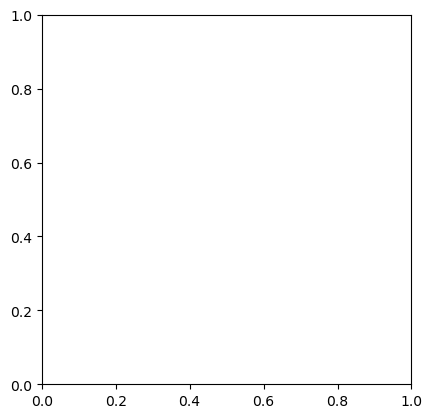

In [16]:
# # ── Augmented model training ───────────────────────────────────────────────────
# # Fresh model with the same architecture — starts from random weights.
# # Only the training data differs from the baseline run.
# NUM_EPOCHS = 200  # match whatever was used for the baseline


# from ipynb.fs.full.baseline import train_one_epoch

# aug_model = build_resnet18().to(DEVICE)

# aug_optimizer = torch.optim.SGD(
#     aug_model.parameters(),
#     lr=0.1,
#     momentum=0.9,
#     weight_decay=5e-4,
#     nesterov=True,
# )
# aug_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     aug_optimizer, T_max=NUM_EPOCHS, eta_min=1e-4
# )

# AUG_CHECKPOINT = os.path.join(MODEL_DIR, 'augmented_best.pth')
# aug_history    = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
# aug_best_acc   = 0.0

# # ── Training loop — identical structure to baseline ───────────────────────────
# # Using the same train_one_epoch() and evaluate() functions defined in Cell 1.
# print(f'Training augmented model — {NUM_EPOCHS} epochs on {DEVICE}')
# print('=' * 70)
# start = time.time()

# for epoch in range(1, NUM_EPOCHS + 1):
#     tr_loss, tr_acc = train_one_epoch(aug_model, aug_train_loader, aug_optimizer, criterion)
#     te_loss, te_acc = evaluate(aug_model, test_loader, criterion)
#     aug_scheduler.step()

#     aug_history['train_acc'].append(tr_acc)
#     aug_history['test_acc'].append(te_acc)
#     aug_history['train_loss'].append(tr_loss)
#     aug_history['test_loss'].append(te_loss)

#     if te_acc > aug_best_acc:
#         aug_best_acc = te_acc
#         torch.save({
#             'epoch'            : epoch,
#             'model_state_dict' : aug_model.state_dict(),
#             'best_acc'         : aug_best_acc,
#         }, AUG_CHECKPOINT)

#     if epoch % 10 == 0:
#         elapsed   = (time.time() - start) / 60
#         remaining = elapsed / epoch * (NUM_EPOCHS - epoch)
#         print(f'Epoch {epoch:3d} | Train Acc: {tr_acc:.3f} | Test Acc: {te_acc:.3f} '
#               f'| ~{remaining:.0f}min left')

# print('=' * 70)
# print(f'Augmented model best test accuracy : {aug_best_acc:.4f}')
# print(f'Checkpoint saved → {AUG_CHECKPOINT}')

---
## Cell 11 — Evaluate augmented model across all corruptions

In [18]:
# Load best augmented weights before evaluation
aug_ckpt = torch.load(AUG_CHECKPOINT, map_location=DEVICE)
aug_model.load_state_dict(aug_ckpt['model_state_dict'])
aug_model.eval()

_, aug_clean_acc = evaluate(aug_model, test_loader, criterion)
aug_corruption_results = {}

print(f'Augmented clean test accuracy: {aug_clean_acc:.4f}\n')

for name, cfg in SEVERITIES.items():
    accs = []
    for sev in cfg['levels']:
        _, acc = evaluate_corruption(aug_model, cfg['fn'], sev, criterion)
        accs.append(acc)
    aug_corruption_results[name] = accs
    print(f'{name:<18}  acc: {"  ".join(f"{a:.3f}" for a in accs)}')

print('\nAugmented model evaluation complete.')

Augmented clean test accuracy: 0.9366

Gaussian Noise      acc: 0.860  0.830  0.713  0.396  0.151
Gaussian Blur       acc: 0.934  0.803  0.372  0.244  0.211
Rotation            acc: 0.921  0.908  0.885  0.424  0.374
Occlusion           acc: 0.933  0.934  0.923  0.900  0.822

Augmented model evaluation complete.


---
## Cell 12 — Baseline vs augmented comparison: degradation curves

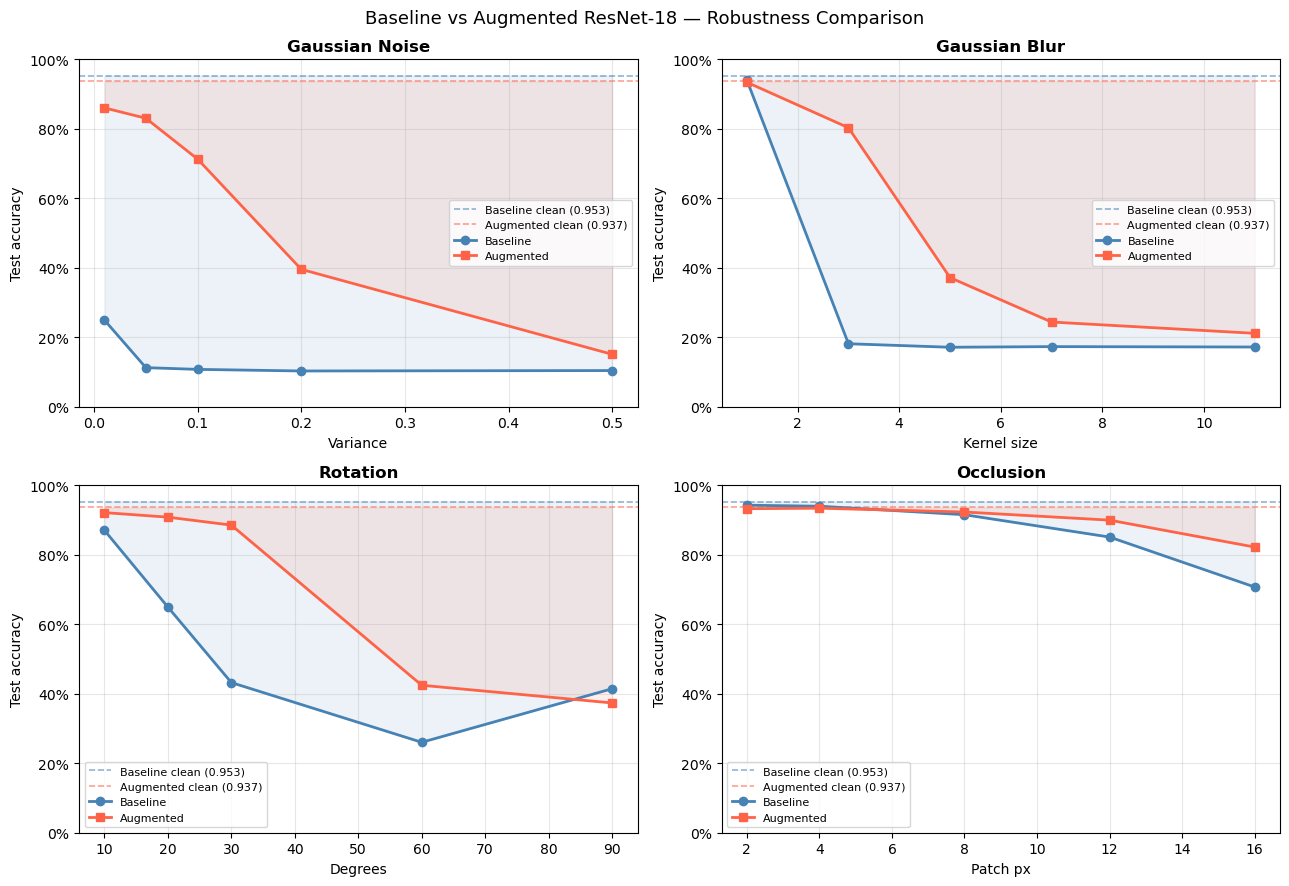

Saved → results/comparison_degradation_curves.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes      = axes.flatten()

for idx, (name, cfg) in enumerate(SEVERITIES.items()):
    ax     = axes[idx]
    levels = cfg['levels']

    baseline_accs  = corruption_results[name]
    augmented_accs = aug_corruption_results[name]

    # Clean accuracy lines for each model
    ax.axhline(y=clean_acc,     color='steelblue', linestyle='--',
               linewidth=1.2, alpha=0.6, label=f'Baseline clean ({clean_acc:.3f})')
    ax.axhline(y=aug_clean_acc, color='tomato',    linestyle='--',
               linewidth=1.2, alpha=0.6, label=f'Augmented clean ({aug_clean_acc:.3f})')

    # Degradation curves
    ax.plot(levels, baseline_accs,  marker='o', linewidth=2,
            color='steelblue', markersize=6, label='Baseline')
    ax.plot(levels, augmented_accs, marker='s', linewidth=2,
            color='tomato',    markersize=6, label='Augmented')

    ax.fill_between(levels, baseline_accs,  clean_acc,     alpha=0.10, color='steelblue')
    ax.fill_between(levels, augmented_accs, aug_clean_acc, alpha=0.10, color='tomato')

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(cfg['label'].capitalize(), fontsize=10)
    ax.set_ylabel('Test accuracy', fontsize=10)
    ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

plt.suptitle('Baseline vs Augmented ResNet-18 — Robustness Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_degradation_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/comparison_degradation_curves.png')

---
## Cell 13 — Confusion matrices: augmented model

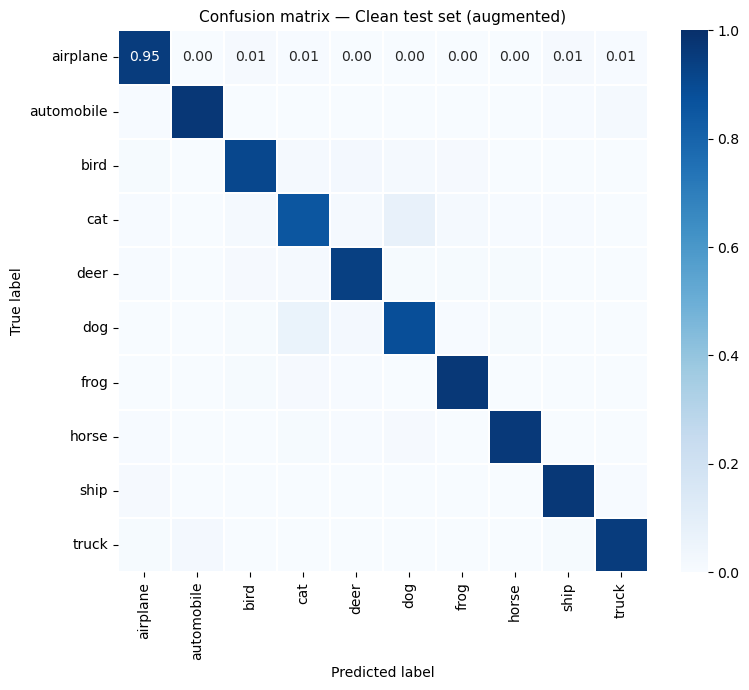

Saved → results/cm_augmented_clean.png


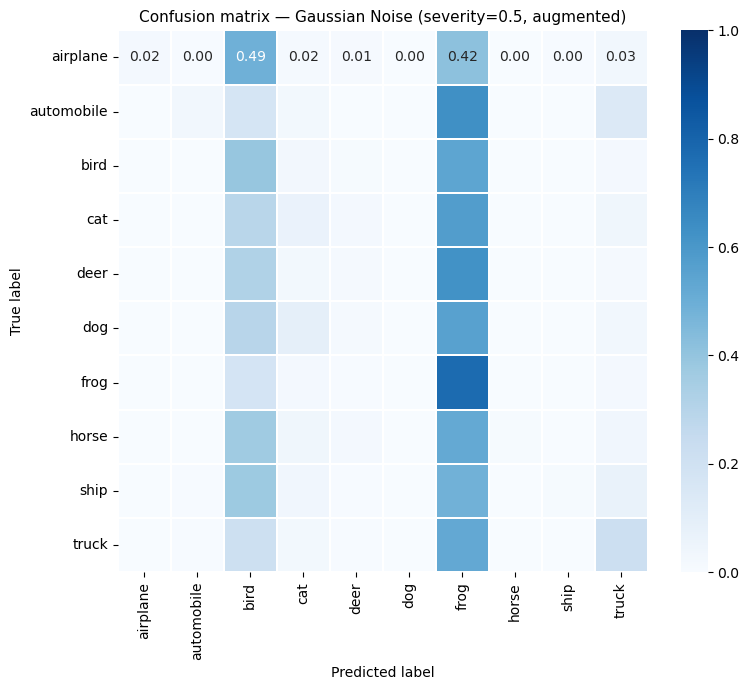

Saved → results/cm_aug_gaussian_noise_worst.png


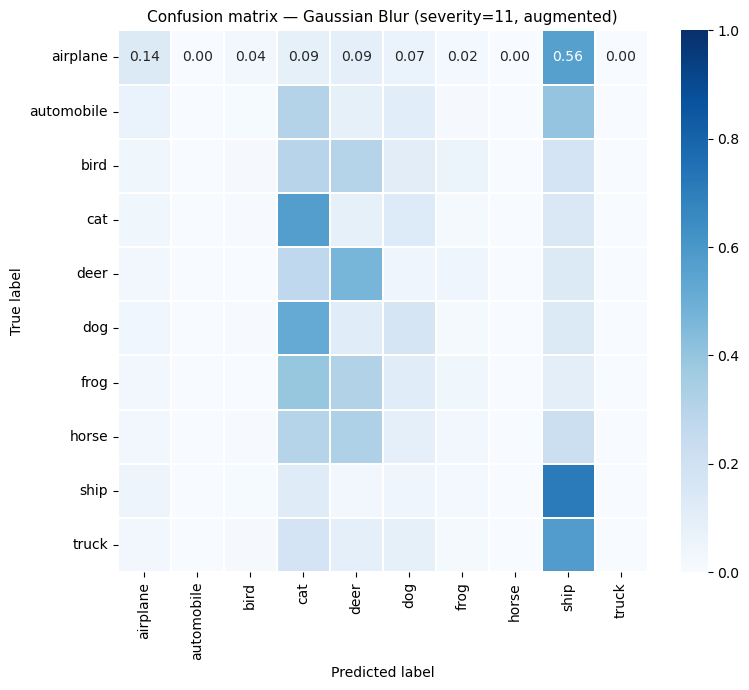

Saved → results/cm_aug_gaussian_blur_worst.png


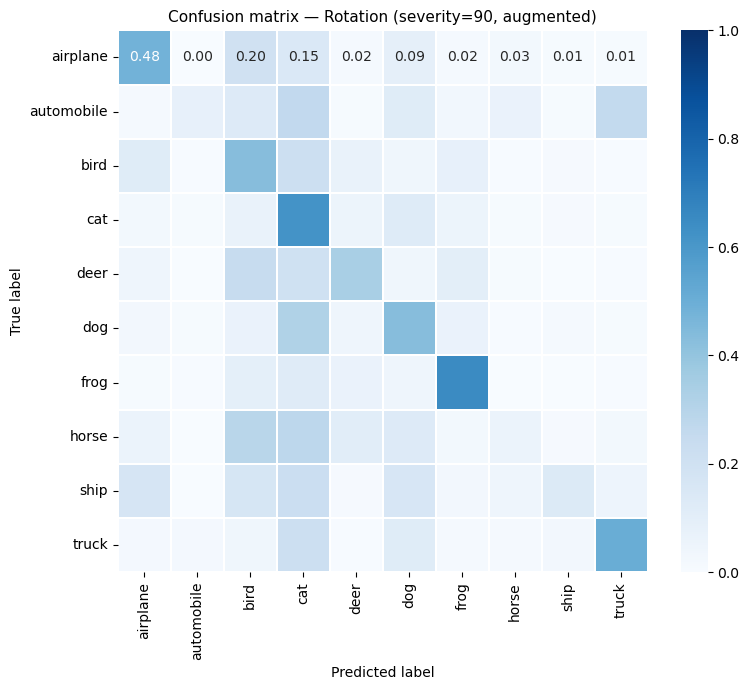

Saved → results/cm_aug_rotation_worst.png


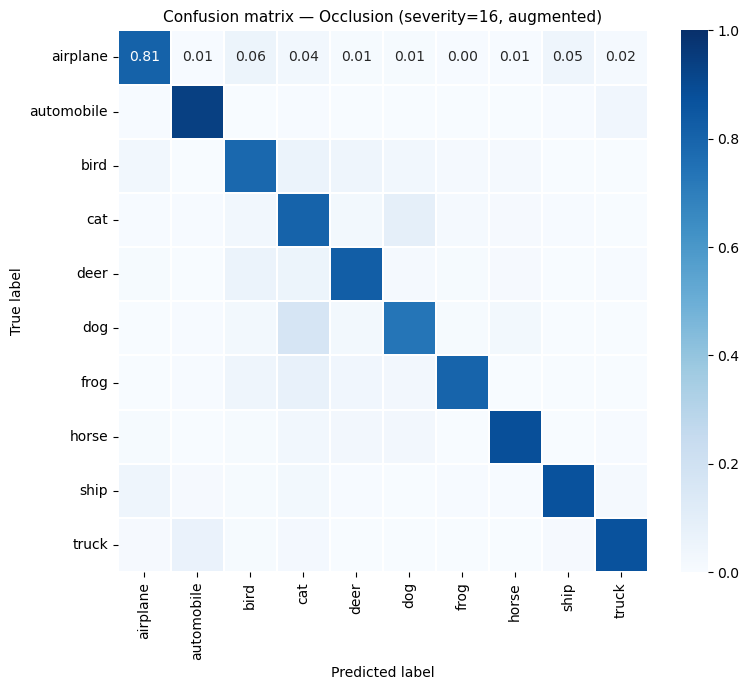

Saved → results/cm_aug_occlusion_worst.png


In [20]:
# Clean confusion matrix for augmented model
true_lbl, pred_lbl = get_all_predictions(aug_model, test_loader)
plot_confusion_matrix(
    true_lbl, pred_lbl,
    title='Confusion matrix — Clean test set (augmented)',
    save_path=os.path.join(RESULTS_DIR, 'cm_augmented_clean.png')
)
print('Saved → results/cm_augmented_clean.png')

# Worst-severity confusion matrices for augmented model
for name, cfg in SEVERITIES.items():
    worst_sev = cfg['levels'][-1]
    corrupted_ds = CorruptedDataset(test_dataset_raw, cfg['fn'], worst_sev, normalise)
    loader = torch.utils.data.DataLoader(
        corrupted_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
    )
    true_lbl, pred_lbl = get_all_predictions(aug_model, loader)
    fname = f'cm_aug_{name.lower().replace(" ", "_")}_worst.png'
    plot_confusion_matrix(
        true_lbl, pred_lbl,
        title=f'Confusion matrix — {name} (severity={worst_sev}, augmented)',
        save_path=os.path.join(RESULTS_DIR, fname)
    )
    print(f'Saved → results/{fname}')

---
## Cell 14 — Summary statistics and final JSON export

In [21]:
# ── Mean accuracy drop across all corruption types and severities ─────────────
# A single number that summarises robustness: lower drop = more robust.
def mean_accuracy_drop(clean, corruption_dict):
    drops = [
        clean - acc
        for accs in corruption_dict.values()
        for acc in accs
    ]
    return np.mean(drops)


base_drop = mean_accuracy_drop(clean_acc, corruption_results)
aug_drop  = mean_accuracy_drop(aug_clean_acc, aug_corruption_results)

print('=' * 55)
print(f'  {"":25}  Baseline   Augmented')
print('=' * 55)
print(f'  {"Clean accuracy":25}  {clean_acc:.4f}     {aug_clean_acc:.4f}')
print(f'  {"Mean accuracy drop":25}  {base_drop:.4f}     {aug_drop:.4f}')
print(f'  {"Robustness improvement":25}  — {(base_drop - aug_drop):.4f}')
print('=' * 55)
print()
print(f'{"Corruption":<18}  {"Baseline (worst)":>16}  {"Augmented (worst)":>17}  {"Δ":>6}')
print('-' * 65)
for name in SEVERITIES:
    b = corruption_results[name][-1]
    a = aug_corruption_results[name][-1]
    print(f'{name:<18}  {b:>16.4f}  {a:>17.4f}  {a - b:>+6.4f}')

# ── Save full results to JSON ──────────────────────────────────────────────────
full_results = {
    'baseline': {
        'clean_accuracy'   : round(clean_acc, 6),
        'mean_drop'        : round(float(base_drop), 6),
        'corruption_accs'  : {
            name: [round(a, 6) for a in accs]
            for name, accs in corruption_results.items()
        },
    },
    'augmented': {
        'clean_accuracy'   : round(aug_clean_acc, 6),
        'mean_drop'        : round(float(aug_drop), 6),
        'corruption_accs'  : {
            name: [round(a, 6) for a in accs]
            for name, accs in aug_corruption_results.items()
        },
    },
    'severity_levels': {
        name: cfg['levels'] for name, cfg in SEVERITIES.items()
    },
}

with open(os.path.join(RESULTS_DIR, 'full_results.json'), 'w') as f:
    json.dump(full_results, f, indent=2)
print('\nSaved → results/full_results.json')

                             Baseline   Augmented
  Clean accuracy             0.9533     0.9366
  Mean accuracy drop         0.4884     0.2596
  Robustness improvement     — 0.2288

Corruption          Baseline (worst)  Augmented (worst)       Δ
-----------------------------------------------------------------
Gaussian Noise                0.1041             0.1509  +0.0468
Gaussian Blur                 0.1719             0.2113  +0.0394
Rotation                      0.4145             0.3736  -0.0409
Occlusion                     0.7074             0.8223  +0.1149

Saved → results/full_results.json


---
## Cell 15 — Full project file structure

After running both notebooks, your `cv_project/` folder should look like this:

```
cv_project/
├── baseline.ipynb
├── robustness_evaluation.ipynb
├── data/
│   └── cifar-10-batches-py/
├── models/
│   ├── baseline_best.pth
│   └── augmented_best.pth
└── results/
    ├── baseline_clean.json
    ├── full_results.json
    ├── sample_images.png
    ├── corruption_preview.png
    ├── baseline_degradation_curves.png
    ├── comparison_degradation_curves.png
    ├── per_class_accuracy_heatmap.png
    ├── cm_clean.png
    ├── cm_augmented_clean.png
    ├── cm_gaussian_noise_worst.png
    ├── cm_gaussian_blur_worst.png
    ├── cm_rotation_worst.png
    ├── cm_occlusion_worst.png
    ├── cm_aug_gaussian_noise_worst.png
    ├── cm_aug_gaussian_blur_worst.png
    ├── cm_aug_rotation_worst.png
    └── cm_aug_occlusion_worst.png
```